# OOF Ablation Study — Grouped Bar Chart

展示去掉每个子模型后 OOF R² 的变化，证明三个模型都有贡献。

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Locate project root by walking up from this notebook's directory
_here = Path(globals().get("__vsc_ipynb_file__", "")).resolve().parent if "__vsc_ipynb_file__" in globals() else Path().resolve()
while _here != _here.parent:
    if (_here / "model_training" / "results").exists():
        break
    _here = _here.parent
RES = _here / "model_training" / "results"

df = pd.read_csv(RES / "oof_ablation.csv")
df_rxn = df[df["rxntype"] != "Overall"].copy()

reactions = df_rxn["rxn_name"].tolist()
full   = df_rxn["OOF_R2_Full_SimAvg"].values
wo_A   = df_rxn["OOF_R2_wo_Avalon"].values
wo_B   = df_rxn["OOF_R2_wo_Avalon_RDKit"].values
wo_C   = df_rxn["OOF_R2_wo_Layered_NonFP"].values

print(f"Loaded {len(df_rxn)} reactions")
print(df_rxn[["rxn_name","OOF_R2_Full_SimAvg","OOF_R2_wo_Avalon","OOF_R2_wo_Avalon_RDKit","OOF_R2_wo_Layered_NonFP"]].to_string(index=False))

Loaded 8 reactions
   rxn_name  OOF_R2_Full_SimAvg  OOF_R2_wo_Avalon  OOF_R2_wo_Avalon_RDKit  OOF_R2_wo_Layered_NonFP
        C–N            0.363503          0.358392                0.362047                 0.358361
     Suzuki            0.385042          0.380087                0.382156                 0.379165
       Heck            0.349710          0.340738                0.346806                 0.344995
Diels-Alder            0.390659          0.380762                0.386846                 0.388973
       SNAr            0.457703          0.452242                0.453752                 0.452162
Sonogashira            0.319170          0.318214                0.311588                 0.307715
    Michael            0.407140          0.406673                0.401207                 0.399389
  Amidation            0.392973          0.385291                0.392626                 0.390473


## Grouped Bar Chart

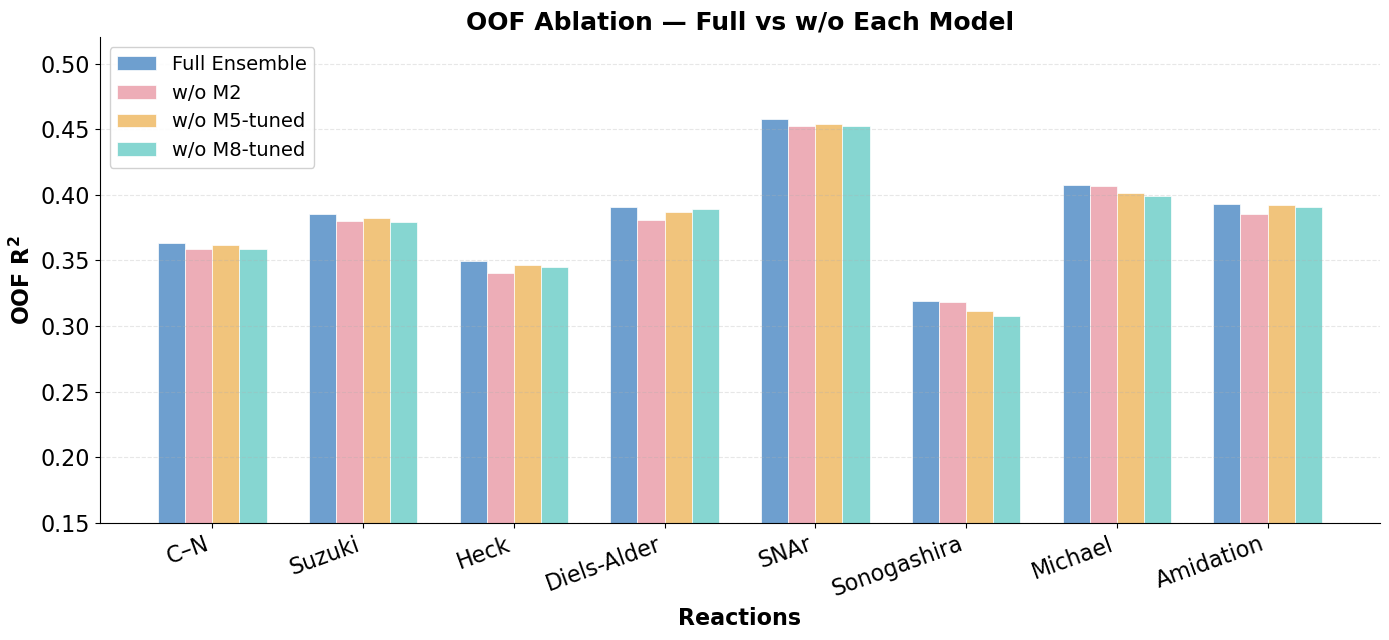

Saved: oof_ablation_grouped_bar.png


In [2]:
x = np.arange(len(reactions))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6.5))

colors = ["#6E9FCF", "#EDADB7", "#f1c47c", "#86D6D1"]
labels = ["Full Ensemble", "w/o M2", "w/o M5-tuned", "w/o M8-tuned"]

ax.bar(x - 1.5*width, full, width, label=labels[0], color=colors[0], edgecolor="white", linewidth=0.5)
ax.bar(x - 0.5*width, wo_A, width, label=labels[1], color=colors[1], edgecolor="white", linewidth=0.5)
ax.bar(x + 0.5*width, wo_B, width, label=labels[2], color=colors[2], edgecolor="white", linewidth=0.5)
ax.bar(x + 1.5*width, wo_C, width, label=labels[3], color=colors[3], edgecolor="white", linewidth=0.5)

ax.set_xlabel("Reactions", fontsize=16,fontweight="bold")
ax.set_ylabel(r"OOF $\mathbf{R^2}$", fontsize=16, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(reactions, fontsize=16, rotation=20, ha="right")
ax.tick_params(axis="y", labelsize=16)
ax.legend(loc="upper left", fontsize=14, framealpha=0.9)
ax.set_ylim(0.15, 0.52)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OOF Ablation — Full vs w/o Each Model", fontsize=18, fontweight="bold")

plt.tight_layout()
fig.savefig(RES / "oof_ablation_grouped_bar.png", dpi=600, bbox_inches="tight")
plt.show()
print("Saved: oof_ablation_grouped_bar.png")

## Combined: OOF Ablation + Test Set Performance (Side-by-Side)

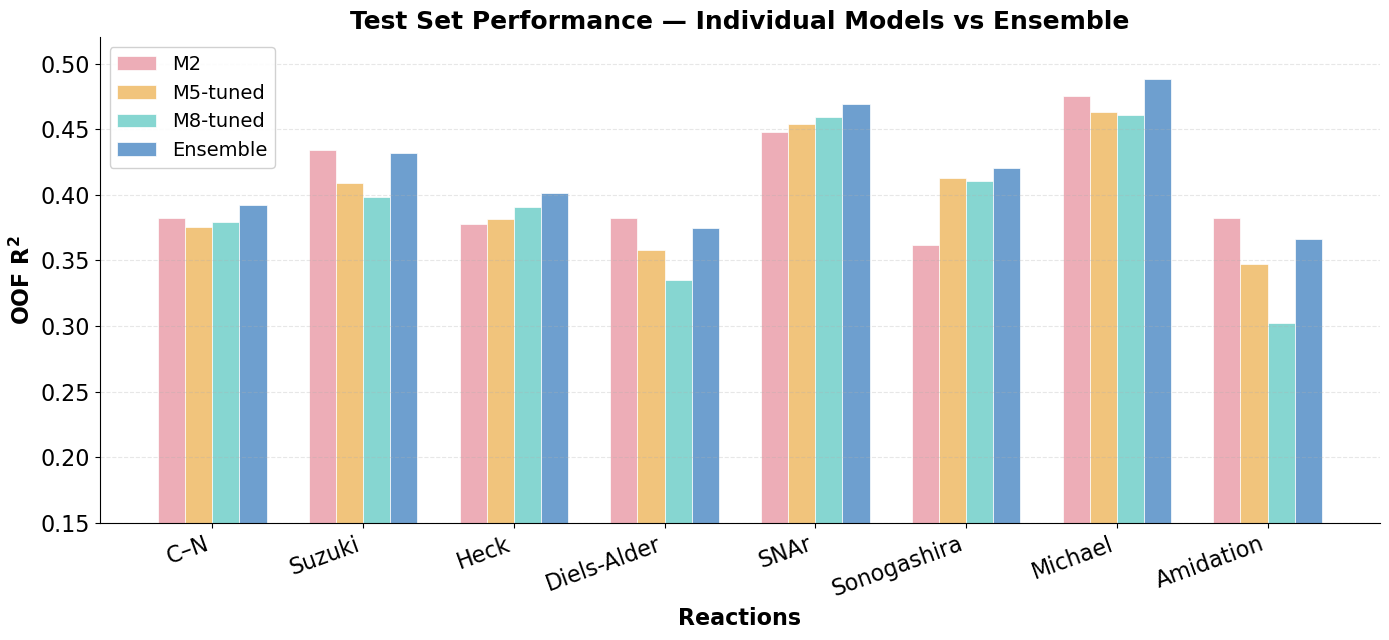

Saved: test_set_comparison_bar.png


In [3]:
# ── Test Set: 单模型 vs Ensemble (Simple Avg) ──
df_test = pd.read_csv(RES / "component_model_external_metrics.csv")

reactions_t = df_test["rxn_name"].tolist()
x = np.arange(len(reactions_t))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6.5))

colors = ["#EDADB7", "#f1c47c", "#86D6D1", "#6E9FCF"]
labels = ["M2", "M5-tuned", "M8-tuned", "Ensemble"]

ax.bar(x - 1.5*width, df_test["test_r2_Avalon"], width, label=labels[0], color=colors[0], edgecolor="white", linewidth=0.5)
ax.bar(x - 0.5*width, df_test["test_r2_Avalon_RDKit"], width, label=labels[1], color=colors[1], edgecolor="white", linewidth=0.5)
ax.bar(x + 0.5*width, df_test["test_r2_Layered_NonFP"], width, label=labels[2], color=colors[2], edgecolor="white", linewidth=0.5)
ax.bar(x + 1.5*width, df_test["test_r2_simple_avg"], width, label=labels[3], color=colors[3], edgecolor="white", linewidth=0.5)

ax.set_xlabel("Reactions", fontsize=16,fontweight="bold")
ax.set_ylabel(r"Test $\mathbf{R^2}$", fontsize=16, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(reactions_t, fontsize=16, rotation=20, ha="right")
ax.tick_params(axis="y", labelsize=16)
ax.legend(loc="upper left", fontsize=14, framealpha=0.9)
ax.set_ylim(0.15, 0.52)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Test Set Performance — Individual Models vs Ensemble", fontsize=18, fontweight="bold")

plt.tight_layout()
fig.savefig(RES / "test_set_comparison_bar.png", dpi=600, bbox_inches="tight")
plt.show()
print("Saved: test_set_comparison_bar.png")